# Salary Prediction - Model Training
Simple Linear Regression to predict salary from years of experience.

## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Load the dataset

In [2]:
df = pd.read_csv('../data/Salary_Data.csv')
df.head()

,Experience Years,Salary
0,1.1,39343
1,1.2,42774
2,1.3,46205
3,1.5,37731
4,2.0,43525


## 3. Explore the data

In [3]:
print(df.shape)
df.info()

(40, 2)
<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Experience Years  40 non-null     float64
 1   Salary            40 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 772.0 bytes


In [4]:
df.describe()

,Experience Years,Salary
count,40.000000,40.000000
mean,5.152500,74743.625000
std,2.663715,25947.122885
min,1.100000,37731.000000
25%,3.200000,56878.250000
50%,4.600000,64472.500000
75%,6.875000,95023.250000
max,10.500000,122391.000000


In [5]:
print('Missing values:\n', df.isnull().sum())
print('Duplicate rows:', df.duplicated().sum())

Missing values:
 Experience Years    0
Salary              0
dtype: int64
Duplicate rows: 0


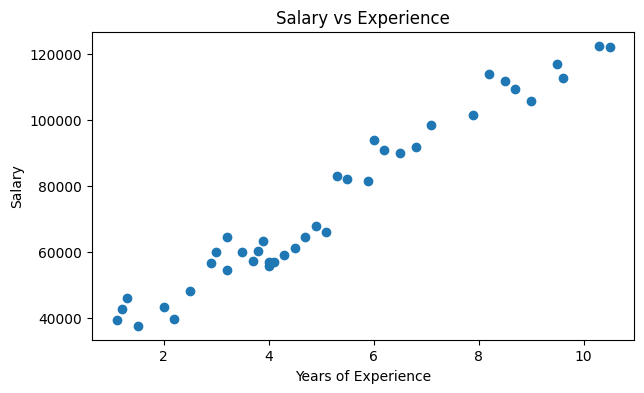

Correlation: 0.978


In [6]:
plt.figure(figsize=(7,4))
plt.scatter(df['Experience Years'], df['Salary'])
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Salary vs Experience')
plt.show()

print('Correlation:', df['Experience Years'].corr(df['Salary']).round(3))

The scatter plot shows a strong, roughly linear relationship, so Linear Regression is a good fit.

## 4. Cleaning / preprocessing
No missing values or duplicates, and both columns are numeric, so no cleaning is needed.

## 5. Features and target

In [7]:
X = df[['Experience Years']]   # feature
y = df['Salary']              # target

## 6. Train/test split (80/20)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(len(X_train), 'train rows,', len(X_test), 'test rows')

32 train rows, 8 test rows


## 7. Train the model

In [9]:
model = LinearRegression()
model.fit(X_train, y_train)
print('Slope (per year):', round(model.coef_[0], 2))
print('Intercept:', round(model.intercept_, 2))

Slope (per year): 9408.03
Intercept: 26716.25


## 8. Evaluate the model

In [10]:
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f'MAE : {mae:,.2f}')
print(f'MSE : {mse:,.2f}')
print(f'RMSE: {rmse:,.2f}')
print(f'R2  : {r2:.4f}')

MAE : 6,419.91
MSE : 48,077,731.17
RMSE: 6,933.81
R2  : 0.9069


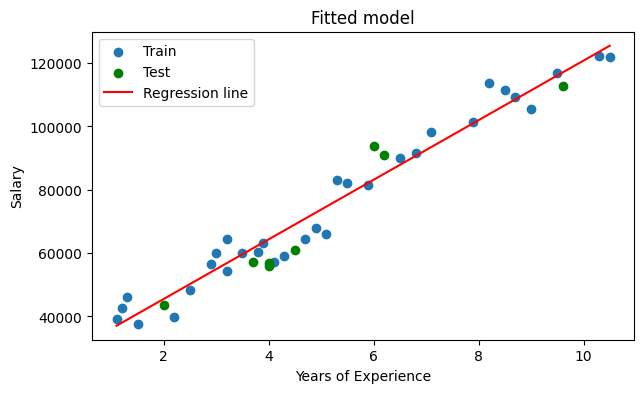

In [11]:
plt.figure(figsize=(7,4))
plt.scatter(X_train, y_train, label='Train')
plt.scatter(X_test, y_test, color='green', label='Test')
plt.plot(X, model.predict(X), color='red', label='Regression line')
plt.xlabel('Years of Experience'); plt.ylabel('Salary'); plt.legend()
plt.title('Fitted model')
plt.show()

## 9. Save the model and metrics

In [12]:
import json, os
os.makedirs('../model', exist_ok=True)
joblib.dump(model, '../model/model.pkl')
with open('../model/metrics.json', 'w') as f:
    json.dump({'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}, f)
print('Saved model/model.pkl and model/metrics.json')

Saved model/model.pkl and model/metrics.json


## 10. Test loading the saved model

In [13]:
loaded = joblib.load('../model/model.pkl')
print('Predicted salary for 5 years:', round(loaded.predict(pd.DataFrame({'Experience Years':[5]}))[0], 2))

Predicted salary for 5 years:

 73756.41
